# Compare LLMs to baseline for final results in Smart Farm use case

## Experiment setup

### Baselines

* Rule-based (see [`RuleBasedFullNearestAdaptation`](../farm/adaptations/rule_based_smart.py) for implementation)
* RL
  * [PPO](farm_rl_ppo.ipynb)
  * [Q-network](farm_rl_qnetwork.ipynb)

### Variants

The following list contains the identifiers of the variants (used in the names of the log files, separated by underscores) and their names (how they are presented in the paper):

* default (*Zero strategy*) = `jinja` (use Jinja prompt templates) + `sd2` (detailed domain description) + `retry1` (max-retries set to 1)
* `strategy` (*High-level strategy*) = default + the LLM is given high-level instructions how to perform the ensemble assignment
* `step-by-step` (*Low-level strategy*) = default + the LLM is given low-level (step-by-step) instructions how to perform the ensemble assignment
* `history5` (*Conversation history*) = default + save last 5 conversations (prompt + LLM response) in the context
* `memory` (*Context summary*) = default + the LLM can summarize the previous conversation, the summary is then provided to it in the next prompt
* `ef` (*Ensemble-first*) = default + use the ensemble-first answer format; all the previous variants use component-first answer format

### Answer formats

#### Component-first

For each component, output a line in the format: `component: assigned ensemble`

Example:

```txt
Drone_1: protecting Field_2
Drone_2: protecting Field_1
Drone_3: protecting Field_2
```

This format is used in all variants except *Ensemble-first*.

#### Ensemble-first

For each ensemble (group), output a line in the format: `ensemble: list of components`

Example:

```txt
protecting Field_1: Drone_2
protecting Field_2: Drone_1, Drone_3
```

## Results

The generated raw results are saved in the [`/results/farm`](../results/farm) folder. However, when re-running this notebook, the newly generated results will be saved in the [`logs`](../logs) folder.
The plots for the paper are produced with the [`farm_plot.ipynb`](farm_plot.ipynb) notebook.

In [ ]:
!ls -l  # check that we are in the correct directory

In [2]:
import subprocess
import os
import textwrap

def run(args, repeats=10, start=1):
    print(args)
    for repeat in range(repeats):
        print(f"  Run #{repeat + start}/{repeats + start - 1}")
        run = ["python", "main.py", *args, "-s", str(repeat + start), "-e", str(repeat + start)]
        # if repeat % 10 == 0:
        #     run.append("--animation")
        
        # disable TF errors
        env = dict(os.environ, TF_CPP_MIN_LOG_LEVEL="3")

        result = subprocess.run(run, capture_output=True, env=env)
        stdout = result.stdout.decode("utf-8")
        stderr = result.stderr.decode("utf-8")

        damage = stdout.partition("damage: ")[2].partition("\n")[0]
        print(f"    Damage: {damage}")

        if stderr:
            stderr_lines = stderr.splitlines()
            stderr = '\n'.join(stderr_lines[-5:])
            print(f"    StdErr: {len(stderr_lines)} lines")
            print(textwrap.indent(stderr, "    "))

### All LLMs for subset of configurations

In [3]:
grid_params_all_llms = {
    "llm": ["configs/llm_gpt4omini.yaml", "configs/llm_o3mini.yaml", "configs/llm_gpt4o.yaml", "configs/llm_claude37sonnet.yaml", "configs/llm_gemini20flash.yaml"],
    "extra": [None, "farm/configs/strategy.yaml"],
}

In [4]:
import itertools

grid = list(itertools.product(*grid_params_all_llms.values()))
print(len(grid))

10


In [5]:
for i, params in enumerate(grid, start=1):
    print(f"{i}/{len(grid)}")

    args = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "configs/jinja.yaml", 
        "DSL/drones.yaml", "farm/configs/simulation_description_2.yaml", "configs/retry1.yaml"]

    for param in params:
        if param is not None:
            args.append(param)

    args.append("farm/configs/no_battery_llm.yaml")

    for config_file in args:
        assert os.path.exists(config_file), f"File {config_file} does not exist"

    # run(args, repeats=1)
    run(args, repeats=2, start=2)

1/10
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'farm/configs/simulation_description_2.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'farm/configs/no_battery_llm.yaml', '../configs/deepnote_0305.yaml']
  Run #2/3
    Damage: 151
  Run #3/3
    Damage: 236
2/10
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'farm/configs/simulation_description_2.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'farm/configs/strategy.yaml', 'farm/configs/no_battery_llm.yaml', '../configs/deepnote_0305.yaml']
  Run #2/3
    Damage: 117
  Run #3/3
    Damage: 117
3/10
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'farm/configs/simulation_description_2.yaml', 'configs/retry1.yaml', 'configs/llm_o3mini.yaml', 'farm/configs/no_battery_llm.yaml', '../configs/deepnote_0305.yaml']
  Run #2/3
    D

### Subset of LLMs for remaining configurations

In [6]:
grid_params_more_configs = {
    "llm": ["configs/llm_gpt4omini.yaml", "configs/llm_o3mini.yaml"],
    "extra": ["farm/configs/goal_step_by_step.yaml", "configs/history_5.yaml", "configs/memory.yaml", "configs/ensemble_first.yaml"],
}

In [7]:
import itertools

grid = list(itertools.product(*grid_params_more_configs.values()))
print(len(grid))

8


In [8]:
for i, params in enumerate(grid, start=1):
    print(f"{i}/{len(grid)}")

    args = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "configs/jinja.yaml", 
        "DSL/drones.yaml", "farm/configs/simulation_description_2.yaml", "configs/retry1.yaml"]

    for param in params:
        if param is not None:
            args.append(param)

    args.append("farm/configs/no_battery_llm.yaml")

    for config_file in args:
        assert os.path.exists(config_file), f"File {config_file} does not exist"

    # run(args, repeats=1)
    run(args, repeats=2, start=2)

1/8
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'farm/configs/simulation_description_2.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'farm/configs/goal_step_by_step.yaml', 'farm/configs/no_battery_llm.yaml', '../configs/deepnote_0305.yaml']
  Run #2/3
    Damage: 71
  Run #3/3
    Damage: 113
2/8
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'farm/configs/simulation_description_2.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'configs/history_5.yaml', 'farm/configs/no_battery_llm.yaml', '../configs/deepnote_0305.yaml']
  Run #2/3
    Damage: 176
  Run #3/3
    Damage: 211
3/8
['farm/configs/default.yaml', 'farm/configs/config_no_battery.yaml', 'configs/jinja.yaml', 'DSL/drones.yaml', 'farm/configs/simulation_description_2.yaml', 'configs/retry1.yaml', 'configs/llm_gpt4omini.yaml', 'configs/memory.yaml', 'farm/configs/no_battery_llm

### Baseline

In [9]:
args = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/rule_based_full_nearest.yaml", "configs/10steps.yaml"]
run(args, repeats=10)

## Results - Damage

In [3]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
baselines = {
    "Rule-based Smart": "/logs/no_battery/rule_based_full_nearest_10steps",
}

In [4]:
allowed_params = {
    "strategy": "Hinted",
    "step-by-step": "Step-by-Step",
    "history5": "History",
    "memory": "Memory",
    "ef": "Ensemble-First",
}

In [5]:
results_folder = Path("/logs/no_battery")

In [14]:
results_files = sorted(results_folder.glob("*/*.csv"))
print(len(results_files), "files found")

64 files found


In [15]:
summary = pd.DataFrame(columns=["llm", "params", "damage"])

In [16]:
for baseline, folder in baselines.items():
    path = Path(folder)
    files = sorted(path.glob("*.csv"))

    for file in files:
        try:
            data = pd.read_csv(file)
            damage = data.iloc[299]["damage"]  # 300th step
            
            llm = "baseline"
            params = baseline

            summary.loc[len(summary)] = [llm, params, damage]
        except pd.errors.EmptyDataError:
            print("Skipping empty file", file)
        except IndexError:
            print("Index error in file", file)

In [14]:
# RL
rl_folders = ["/logs/no_battery/rl1/", "/logs/no_battery/rl2/", "/logs/no_battery/rl3/"]
allowed_rl = {
    "ppo_10steps": "PPO",
    "ppo_10steps_rs5": "PPO + reward shaping",
    "q_network_10steps": "Q-Network",
    "q_network_10steps_rs5": "Q-Network + reward shaping",
}

In [18]:
for folder in rl_folders:
    for file in Path(folder).glob("*.csv"):
        if file.stem not in allowed_rl:
            continue
        data = pd.read_csv(file)
        damage = data.iloc[-10:]["damage"].mean()

        summary.loc[len(summary)] = [file.stem, "RL", damage]

In [19]:
for file in results_files:
    try:
        name = file.stem
        if "jinja_sd2_retry1" not in name:
            continue

        data = pd.read_csv(file)
        damage = data.iloc[299]["damage"]  # 300th step
                
        parts = name.split("_")
        llm = parts[3]
        params = []
        for param in allowed_params:
            if param in name:
                params.append(allowed_params[param])
        if params == []:
            params = ["Default"]
        params = ",\n".join(params)
        
        summary.loc[len(summary)] = [llm, params, damage]
    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

summary.to_csv(results_folder / "summary.csv", index=False)

In [6]:
summary = pd.read_csv(results_folder / "summary.csv")

In [7]:
palette = {
    "baseline": "tab:gray",
    "ppo_10steps": "dimgray",
    "ppo_10steps_rs5": "gray",
    "q_network_10steps": "darkgray",
    "q_network_10steps_rs5": "lightgray",
    "gpt4omini": "tab:red",
    # "claude35haiku": "tab:blue",
    "gemini20flash": "tab:green",
    "gpt4o": "tab:orange",
    "claude37sonnet": "tab:cyan",
    "o3mini": "tab:pink",
}

In [16]:
baseline_names = {
    "baseline": "Rule-based",
}
baseline_names.update(allowed_rl)
llm_names = {
    "gpt4omini": "GPT-4o mini",
    # "claude35haiku": "Claude 3.5 Haiku",
    "gemini20flash": "Gemini 2.0 Flash",
    "gpt4o": "GPT-4o",
    "claude37sonnet": "Claude 3.7 Sonnet",
    "o3mini": "OpenAI o3-mini",
}
all_names = {**baseline_names, **llm_names}
summary['LLM'] = summary['llm'].map(all_names)
palette_baselines = {v: palette[k] for k, v in baseline_names.items()}
palette_LLM = {v: palette[k] for k, v in llm_names.items()}

In [23]:
summary

,llm,params,damage,LLM
0,baseline,Rule-based Smart,31.0,Rule-based
1,baseline,Rule-based Smart,31.0,Rule-based
2,baseline,Rule-based Smart,27.0,Rule-based
3,baseline,Rule-based Smart,32.0,Rule-based
4,baseline,Rule-based Smart,24.0,Rule-based
...,...,...,...,...
71,o3mini,Step-by-Step,44.0,OpenAI o3-mini
72,o3mini,Step-by-Step,48.0,OpenAI o3-mini
73,o3mini,Hinted,30.0,OpenAI o3-mini
74,o3mini,Hinted,34.0,OpenAI o3-mini


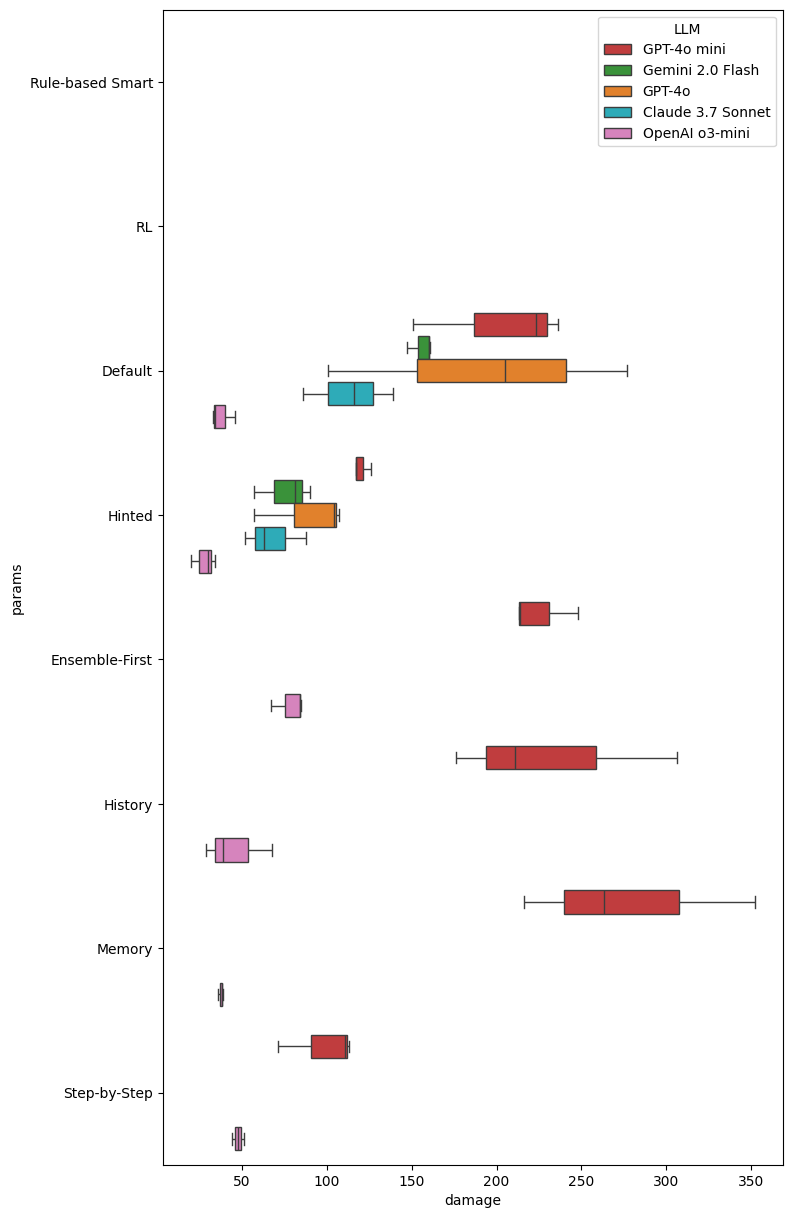

In [24]:
fig, ax = plt.subplots(figsize=(8, 15))
sns.boxplot(x="damage", y="params", hue="LLM", data=summary, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

In [11]:
rows_baselines = [*baselines.keys(), "RL"]
rows_llm = ["Default", "Hinted", "Step-by-Step", "History", "Memory", "Ensemble-First"]

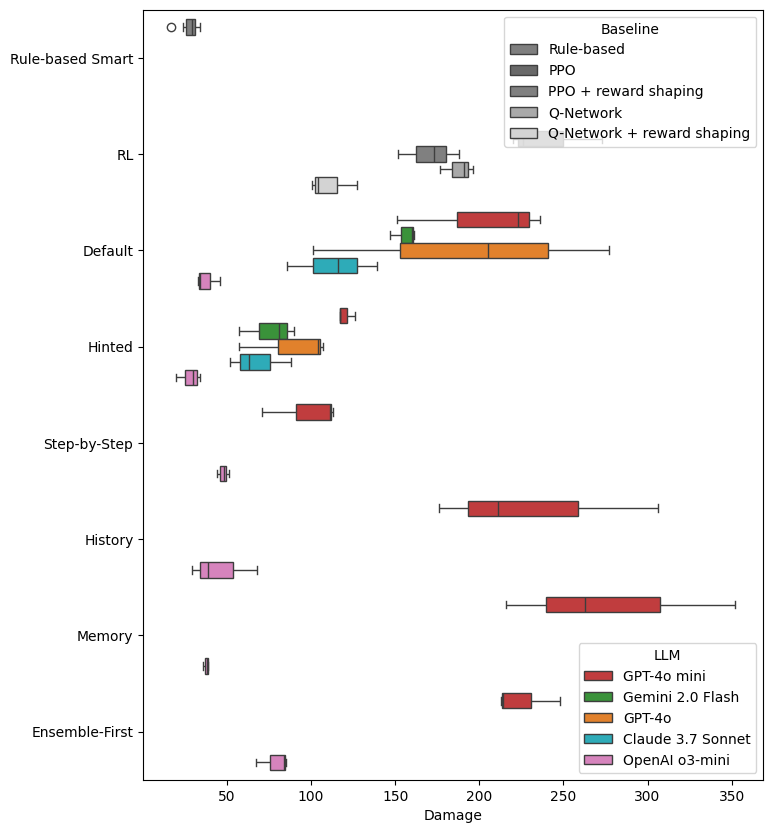

Saved as ../0305/logs/no_battery/damage_box.pdf


In [44]:
fig, ax = plt.subplots(figsize=(8, 10))

ax_baselines = sns.boxplot(x="damage", y="params", hue="LLM", data=summary[summary["params"].isin(rows_baselines)], ax=ax, palette=palette_baselines, hue_order=palette_baselines.keys(), order=rows_baselines)
handles_baselines, labels_baselines = ax_baselines.get_legend_handles_labels()
ax_baselines.get_legend().remove()

ax_llm = sns.boxplot(x="damage", y="params", hue="LLM", data=summary[summary["params"].isin(rows_llm)], ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), order=rows_llm)
handles_llm, labels_llm = ax_llm.get_legend_handles_labels()
handles_llm = handles_llm[len(handles_baselines):]
labels_llm = labels_llm[len(labels_baselines):]
ax_llm.get_legend().remove()

legend_baselines = plt.legend(handles_baselines, labels_baselines, title="Baseline", loc="upper right")
plt.gca().add_artist(legend_baselines)
legend_llm = plt.legend(handles_llm, labels_llm, title="LLM", loc="lower right")

plt.ylabel("")
plt.xlabel("Damage")
plt.savefig(results_folder / "damage_box.pdf", bbox_inches="tight")
plt.show()
print(f"Saved as {results_folder / 'damage_box.pdf'}")

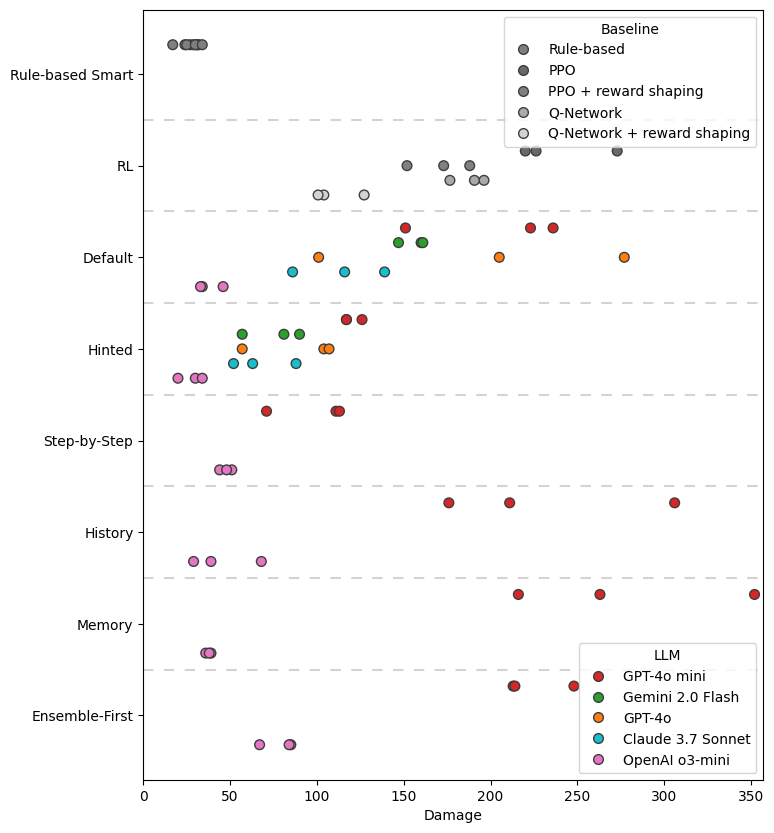

Saved as ../0305/logs/no_battery/damage_strip.pdf


In [42]:
fig, ax = plt.subplots(figsize=(8, 10))
plot_kwargs = {
    "dodge": True,
    "jitter": False,
    "size": 7,
    "linewidth": 1,
}

ax_baselines = sns.stripplot(x="damage", y="params", hue="LLM", data=summary[summary["params"].isin(rows_baselines)], ax=ax, palette=palette_baselines, hue_order=palette_baselines.keys(), order=rows_baselines, **plot_kwargs)
handles_baselines, labels_baselines = ax_baselines.get_legend_handles_labels()
ax_baselines.get_legend().remove()

ax_llm = sns.stripplot(x="damage", y="params", hue="LLM", data=summary[summary["params"].isin(rows_llm)], ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), order=rows_llm, **plot_kwargs)
handles_llm, labels_llm = ax_llm.get_legend_handles_labels()
handles_llm = handles_llm[len(handles_baselines):]
labels_llm = labels_llm[len(labels_baselines):]
ax_llm.get_legend().remove()

legend_baselines = plt.legend(handles_baselines, labels_baselines, title="Baseline", loc="upper right")
plt.gca().add_artist(legend_baselines)
legend_llm = plt.legend(handles_llm, labels_llm, title="LLM", loc="lower right")

# add lines separating params
for y in range(0, len(rows_baselines) + len(rows_llm) - 1):
  plt.plot([0, summary['damage'].max() + 5], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')

plt.xlim(0, summary['damage'].max() + 5)
plt.ylabel("")
plt.xlabel("Damage")
plt.savefig(results_folder / "damage_strip.pdf", bbox_inches="tight")
plt.show()
print(f"Saved as {results_folder / 'damage_strip.pdf'}")

## Results - errors and retries

In [26]:
errors = pd.DataFrame(columns=["llm", "params", "total", "final", "retries", "filename"])

In [27]:
log_files = sorted(results_folder.glob("*/*.ansi"))

for file in log_files:
    try:
        name = file.stem
        if "jinja_sd2_retry1" not in name:
            continue

        with open(file, 'r') as f:
            content = f.read()
            total = content.count("Before retry:")
            final = content.count("Error in final assignment:")
            retries = content.count("There were some errors in your final group assignment.")
                
        parts = name.split("_")
        llm = parts[3]
        params = []
        for param in allowed_params:
            if param in name:
                params.append(allowed_params[param])
        if params == []:
            params = ["Default"]
        params = ",\n".join(params)

        errors.loc[len(errors)] = [llm, params, total, final, retries, name]
    except FileNotFoundError:
            print("File not found: ", file)

errors.to_csv(results_folder / "errors.csv", index=False)

In [7]:
errors = pd.read_csv(results_folder / "errors.csv")

In [28]:
errors

,llm,params,total,final,retries,filename
0,claude37sonnet,Default,0,0,0,001-2025-03-07-10-42-13-jinja_sd2_retry1_claud...
1,claude37sonnet,Default,0,0,0,002-2025-03-07-16-24-00-jinja_sd2_retry1_claud...
2,claude37sonnet,Default,0,0,0,003-2025-03-07-16-28-51-jinja_sd2_retry1_claud...
3,claude37sonnet,Hinted,0,0,0,001-2025-03-07-10-46-32-jinja_sd2_retry1_claud...
4,claude37sonnet,Hinted,0,0,0,002-2025-03-07-16-33-28-jinja_sd2_retry1_claud...
5,claude37sonnet,Hinted,0,0,0,003-2025-03-07-16-37-53-jinja_sd2_retry1_claud...
6,gemini20flash,Default,9,2,7,001-2025-03-07-10-51-12-jinja_sd2_retry1_gemin...
7,gemini20flash,Default,10,4,6,002-2025-03-07-16-42-27-jinja_sd2_retry1_gemin...
8,gemini20flash,Default,13,4,9,003-2025-03-07-16-45-29-jinja_sd2_retry1_gemin...
9,gemini20flash,Hinted,12,4,8,001-2025-03-07-11-37-24-jinja_sd2_retry1_gemin...


In [9]:
errors[errors["retries"] > 0]

,llm,params,total,final,retries,filename
6,gemini20flash,Default,9,2,7,001-2025-03-07-10-51-12-jinja_sd2_retry1_gemin...
7,gemini20flash,Default,10,4,6,002-2025-03-07-16-42-27-jinja_sd2_retry1_gemin...
8,gemini20flash,Default,13,4,9,003-2025-03-07-16-45-29-jinja_sd2_retry1_gemin...
9,gemini20flash,Hinted,12,4,8,001-2025-03-07-11-37-24-jinja_sd2_retry1_gemin...
10,gemini20flash,Hinted,12,4,8,002-2025-03-07-16-48-47-jinja_sd2_retry1_gemin...
11,gemini20flash,Hinted,10,3,7,003-2025-03-07-16-51-55-jinja_sd2_retry1_gemin...
12,gpt4o,Default,0,0,2,001-2025-03-07-10-28-13-jinja_sd2_retry1_gpt4o
15,gpt4o,Hinted,2,2,7,001-2025-03-07-10-34-58-jinja_sd2_retry1_gpt4o...
21,gpt4omini,Ensemble-First,38,14,17,001-2025-03-07-12-32-04-jinja_sd2_retry1_gpt4o...
22,gpt4omini,Ensemble-First,26,11,12,002-2025-03-07-17-24-26-jinja_sd2_retry1_gpt4o...


In [30]:
errors['LLM'] = errors['llm'].map(all_names)

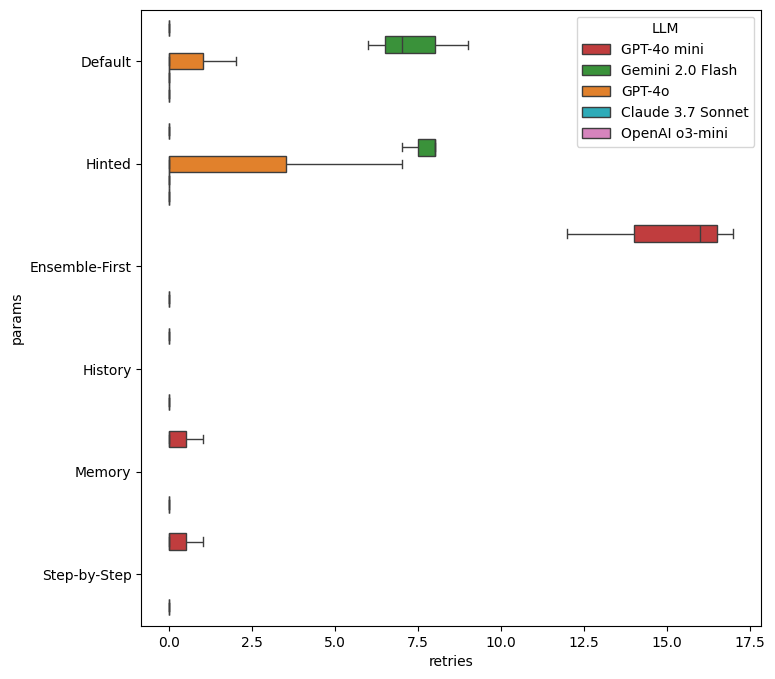

In [31]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(x="retries", y="params", hue="LLM", data=errors, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

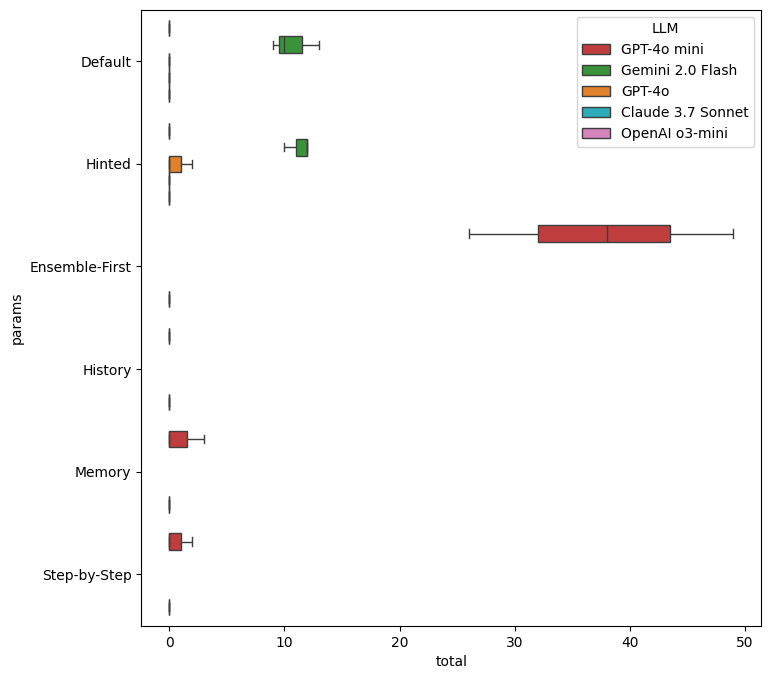

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(x="total", y="params", hue="LLM", data=errors, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

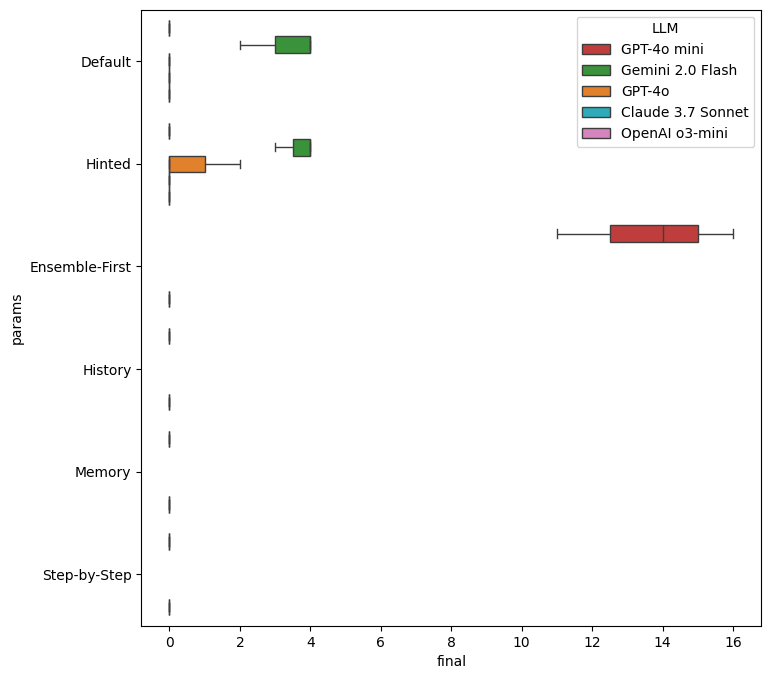

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(x="final", y="params", hue="LLM", data=errors, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()